In [ ]:
import pickle
import random

import pandas as pd
import numpy as np

from scipy.stats import norm

from src.utils.modelling_plots.modelplots import auc_plot_loo_val_ext
from src.utils.modelling_plots.modelplots import auc_plot_loo_val
from src.utils.modelling_plots.modelplots import plot_violin

from src.utils.model_optimizer.optimizer import get_metrics_splits_ic

### Globals

In [ ]:
FOLDER_SAVE = "./data/optimal_models/LOPE_T2_opt/"
DATE_MODEL = "090325"
PATH_MODEL_SAVE = FOLDER_SAVE + "lope_t2_94_optimal_031025.sav"
PATH_INPUT_MODEL_FINAL = FOLDER_SAVE + "input_model_ctr_t2_v7_94g_090325.csv"
PATH_THR_OPTIMAL = FOLDER_SAVE + "lope_t2_94_opt_thr_031025.txt"

### Functions

In [4]:
def get_prediciton_thr(y_scores, optimal_thr):
    y_pred = []
    for i in range(len(y_scores)):
        if y_scores[i] >= optimal_thr:
            y_pred.append(1)
        else:
            y_pred.append(0)
    return y_pred

In [5]:

def get_ic(mean_i, std_i, n_values):
    alpha = 0.05
    z_score = norm.ppf(1 - alpha / 2)
    se_value = std_i / np.sqrt(n_values)
    ci_lower = mean_i - z_score * se_value
    ci_upper = mean_i + z_score * se_value
    return round(ci_lower), round(ci_upper)

### Loading data

In [6]:
df_input = pd.read_csv(PATH_INPUT_MODEL_FINAL)

In [ ]:
df_input

In [8]:
all_samples = list(df_input["sample"])
classes = list(df_input["class"])
datasets = list(df_input["group"])

In [9]:
samples_train = [sample for i, sample in enumerate(all_samples) if df_input["group"][i] == "train"]
samples_val = [sample for i, sample in enumerate(all_samples) if df_input["group"][i] == "validation"]

In [10]:
print(f"Total number of samples {len(classes)}")
print(f"Number Control {classes.count(0)}")
print(f"Number LOPEs {classes.count(1)}")

Total number of samples 161
Number Control 120
Number LOPEs 41


In [11]:
count_train = datasets.count("train")
count_validation = datasets.count("validation")

percentage_train = round(100*count_train/len(datasets))
percentage_validation = round(100*count_validation/len(datasets))

print("Number of patients in train/test: ", count_train)
print("Number of patients in validation: ", count_validation)
print(f"Percentage Train: {percentage_train}%")
print(f"Percentage Validation: {percentage_validation}%")

Number of patients in train/test:  117
Number of patients in validation:  44
Percentage Train: 73%
Percentage Validation: 27%


In [12]:
clf_loaded = pickle.load(open(PATH_MODEL_SAVE, 'rb'))

In [13]:
idx_train = [i for i, x in enumerate(df_input["group"]) if x == "train"]
idx_validation = [i for i, x in enumerate(df_input["group"]) if x == "validation"]
x_train = (df_input.values)[idx_train, 3:]
x_validation = (df_input.values)[idx_validation, 3:]
y_train = list((df_input.values)[idx_train, 1])
y_validation = list((df_input.values)[idx_validation, 1])

In [14]:
counts_eope_train = y_train.count(1)
counts_eope_validation = y_validation.count(1)
counts_ctr_train = y_train.count(0)
counts_ctr_validation = y_validation.count(0)
total_eopes = counts_eope_train+counts_eope_validation
percentage_eope_train_total = round(100*counts_eope_train/total_eopes)
percentage_eope_validation_total = round(100*counts_eope_validation/total_eopes)
print(f"CTRs Train {counts_ctr_train}")
print(f"CTRs Validation {counts_ctr_validation}")
print(f"LOPEs Train {counts_eope_train} | Percentage of total EOPEs {percentage_eope_train_total}%")
print(f"LOPEs Validation {counts_eope_validation} | Percentage of total EOPEs {percentage_eope_validation_total}%")

CTRs Train 83
CTRs Validation 37
LOPEs Train 34 | Percentage of total EOPEs 83%
LOPEs Validation 7 | Percentage of total EOPEs 17%


In [15]:
with open(PATH_THR_OPTIMAL, "r") as file_in:
    loaded_thr = float(file_in.read().strip())

In [16]:
# loaded_thr = 0.3
print(f"Optimal THR of the model: {loaded_thr}")



Optimal THR of the model: 0.4180632173814439


### Metrics

In [17]:
y_scores_train = clf_loaded.predict(x_train)
y_pred_train = get_prediciton_thr(y_scores_train, loaded_thr)
train_metrics_loo = get_metrics_splits_ic(y_train, np.array(y_pred_train), 6)

In [18]:
print("#### TRAINING METRICS ####")
for metric, value in train_metrics_loo.items():
    ci_l, ci_u = get_ic(value[0], value[1], len(y_pred_train))
    print(f"\t{metric}: {value[0]} +/- {value[1]}, [{ci_l}, {ci_u}]")

#### TRAINING METRICS ####
	Accuracy: 92 +/- 11.46, [90, 94]
	Recall: 77 +/- 36.05, [70, 84]
	F1_Score: 89 +/- 12.93, [87, 91]
	AUC: 88 +/- 18.82, [85, 91]
	Specificity: 98 +/- 3.1, [97, 99]
	Precision: 79 +/- 39.34, [72, 86]
	PPV: 79 +/- 39.34, [72, 86]
	NPV: 83 +/- 36.61, [76, 90]
	FDR: 21 +/- 39.34, [14, 28]


In [19]:
print("TRAIN CONFUSION MATRIX")
train_tn, train_fp, train_fn, train_tp = metrics.confusion_matrix(list(y_train), y_pred_train).ravel()
print(f"TN: {train_tn}")
print(f"FP: {train_fp}")
print(f"FN: {train_fn}")
print(f"TP: {train_tp}")

TRAIN CONFUSION MATRIX
TN: 81
FP: 2
FN: 4
TP: 30


In [20]:
y_scores_val = clf_loaded.predict(x_validation)
y_pred_val = get_prediciton_thr(y_scores_val, loaded_thr)
val_metrics_loo = get_metrics_splits_ic(y_validation, np.array(y_pred_val), 2)

In [21]:
print("#### VALIDATION METRICS ####")
for metric, value in val_metrics_loo.items():
    ci_l, ci_u = get_ic(value[0], value[1], len(y_pred_val))
    print(f"\t{metric}: {value[0]} +/- {value[1]}, [{ci_l}, {ci_u}]")

#### VALIDATION METRICS ####
	Accuracy: 91 +/- 0.0, [91, 91]
	Recall: 88 +/- 17.68, [83, 93]
	F1_Score: 75 +/- 0.0, [75, 75]
	AUC: 90 +/- 7.07, [88, 92]
	Specificity: 92 +/- 3.54, [91, 93]
	Precision: 68 +/- 10.61, [65, 71]
	PPV: 68 +/- 10.61, [65, 71]
	NPV: 97 +/- 4.24, [96, 98]
	FDR: 32 +/- 10.61, [29, 35]


In [22]:
print("VALIDATION CONFUSION MATRIX")
val_tn, val_fp, val_fn, val_tp = metrics.confusion_matrix(list(y_validation), y_pred_val).ravel()
print(f"TN: {val_tn}")
print(f"FP: {val_fp}")
print(f"FN: {val_fn}")
print(f"TP: {val_tp}")

VALIDATION CONFUSION MATRIX
TN: 34
FP: 3
FN: 1
TP: 6


In [23]:
print("TRAIN + VALIDATION CONFUSION MATRIX")
print(f"TN: {val_tn+train_tn}")
print(f"FP: {train_fp+val_fp}")
print(f"FN: {train_fn+val_fn}")
print(f"TP: {train_tp+val_tp}")

TRAIN + VALIDATION CONFUSION MATRIX
TN: 115
FP: 5
FN: 5
TP: 36


### AUC Final Model

In [24]:

train_fpr, train_tpr, train_thresholds = metrics.roc_curve(y_train, y_scores_train)
val_fpr, val_tpr, val_thresholds = metrics.roc_curve(y_validation, y_scores_val)
auc_train = round(100*metrics.auc(train_fpr, train_tpr))
auc_val = round(100*metrics.auc(val_fpr, val_tpr))

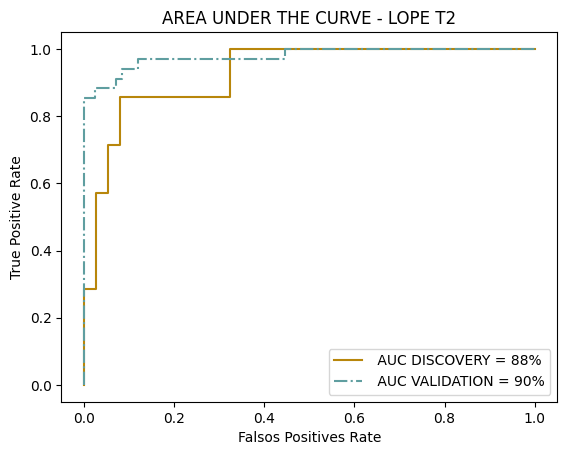

In [25]:
auc_plot_loo_val(y_test=y_validation,
                 y_test_scores=y_scores_val,
                 y_val=y_train,
                 y_val_scores=y_scores_train,
                 dataset_name="LOPE T2",
                 auc_test=train_metrics_loo["AUC"][0],
                 # auc_test=auc_train,
                 auc_val=val_metrics_loo["AUC"][0],
                 # auc_val=auc_val,
                 num_splits_train=1,
                 num_splits_val=1)

### Violin Plot

/Users/migual/Documents/iPremom/Repositories/tg-data-analysis-cfRNA/src/utils/modelling_plots/modelplots.py:254: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Class", y="Probability", data=train_df, ax=axes[0],
/Users/migual/Documents/iPremom/Repositories/tg-data-analysis-cfRNA/src/utils/modelling_plots/modelplots.py:258: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Class", y="Probability", data=train_df, ax=axes[0],
/Users/migual/Documents/iPremom/Repositories/tg-data-analysis-cfRNA/src/utils/modelling_plots/modelplots.py:268: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

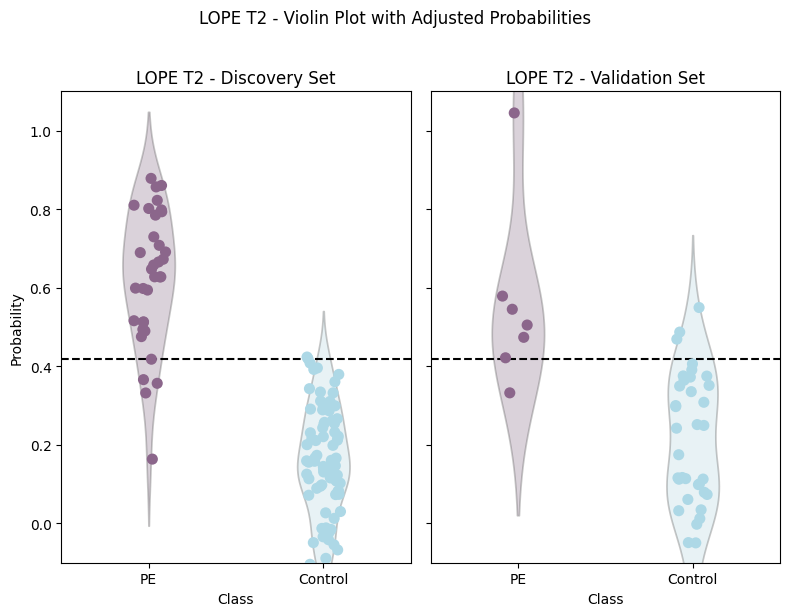

In [26]:
color_pe = "#8B668B"
title = "LOPE T2"
plot_violin(title, y_train, y_scores_train, y_validation, y_scores_val, loaded_thr, color_pe)

In [27]:
file_t1 = "lope_t2_prediction.csv"
with open(file_t1, "w") as file_out:
    file_out.write("Sample,Dataset,Real_Value,Predicted_Value\n")
    for i, sample_i in enumerate(samples_train):
        values_print = [sample_i, "train", str(y_train[i]), str(y_pred_train[i])]
        file_out.write(",".join(values_print))
        file_out.write("\n")
    for i, sample_i in enumerate(samples_val):
        values_print = [sample_i, "validation", str(y_validation[i]), str(y_pred_val[i])]
        file_out.write(",".join(values_print))
        file_out.write("\n")

### External Validation

In [28]:
results_external = "/Users/migual/Documents/iPremom/Data/public_data/MFR/results_external_validation/lope_t2_2g.csv"

In [29]:
ext_probs = []
ext_thr = []
ext_classes = []
extrapolated_ext_prob = []
extrapolated_ext_violin = []
with open(results_external, "r") as file_in:
    header = file_in.readline()
    for line in file_in.readlines():
        splits = line.strip().split(",")
        prob_sample = float(splits[2])
        train_thr = float(splits[3])
        ext_classes.append(int(splits[1]))
        ext_probs.append(prob_sample)
        ext_thr.append(train_thr)
        extrapolation = (loaded_thr/train_thr)*prob_sample
        if extrapolation > 1:
            extrapolation = 1
        if extrapolation < loaded_thr:
            extrapolation_violin = random.uniform(loaded_thr-0.3, loaded_thr-0.05)
        else:
            extrapolation_violin = random.uniform(loaded_thr+0.3, loaded_thr+0.01)
        extrapolated_ext_prob.append(extrapolation)
        extrapolated_ext_violin.append(extrapolation_violin)

In [37]:
idx_split = 29
y_scores_ext = extrapolated_ext_prob[0:idx_split] + ext_classes[idx_split:]

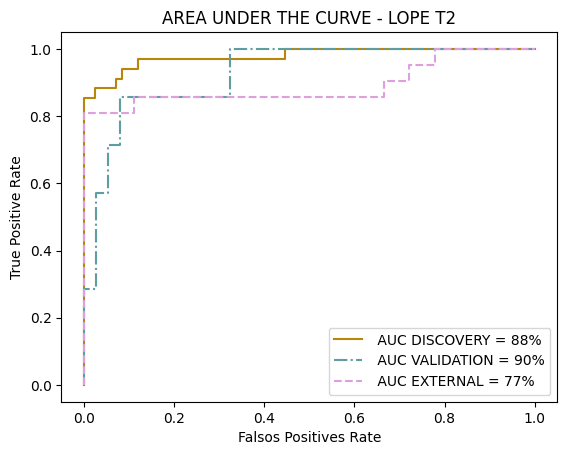

In [38]:
auc_plot_loo_val_ext(y_test=y_train,
                 y_test_scores=y_scores_train,
                 y_val=y_validation,
                 y_val_scores=y_scores_val,
                 y_ext=ext_classes,
                 y_ext_scores=y_scores_ext,
                 dataset_name="LOPE T2",
                 auc_test=train_metrics_loo["AUC"][0],
                 auc_val=val_metrics_loo["AUC"][0],
                 auc_ext=77,
                 num_splits_train=1,
                 num_splits_val=1,
                 num_splits_ext=1)

/Users/migual/Documents/iPremom/Repositories/tg-data-analysis-cfRNA/src/utils/modelling_plots/modelplots.py:254: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Class", y="Probability", data=train_df, ax=axes[0],
/Users/migual/Documents/iPremom/Repositories/tg-data-analysis-cfRNA/src/utils/modelling_plots/modelplots.py:258: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Class", y="Probability", data=train_df, ax=axes[0],
/Users/migual/Documents/iPremom/Repositories/tg-data-analysis-cfRNA/src/utils/modelling_plots/modelplots.py:268: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

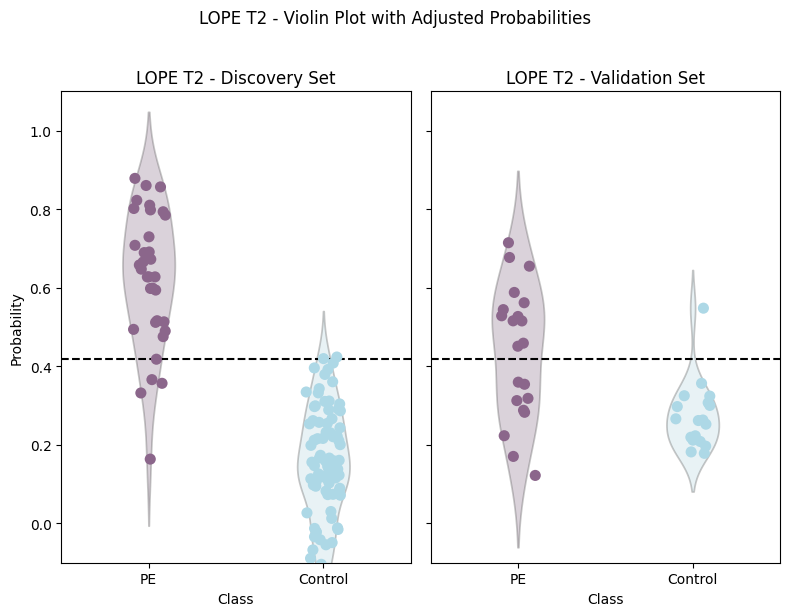

In [39]:
color_pe = "#8B668B"
title = "LOPE T2"
plot_violin(title, y_train, y_scores_train, ext_classes, extrapolated_ext_violin, loaded_thr, color_pe)